In [ ]:
# Collinearity Case - Apple market risk (OLS Model)

An OLS model will be analyzed. The statistical arguments for why the model, although it has very good coefficients, is not recommended due to its strong collinearity between its variables will be explained.

The dependent variable will be Apple stock (AAPL) and the independent variables will be:

*   Dow Jones index.
*   Federal Reserve rates (USA).
*   Consumer Price Index (USA).

The model is based on the case presented in the GitHub repository called "MARKET_RISK-OLS_Model," which already explains Python modeling in detail. Therefore, it will not be explained in such detail in this model. The purpose of this repository is to demonstrate a case of collinearity and explain it with statistical arguments.

In [ ]:
# Extract data (apple historical data) from Yahoo Finance.

In [ ]:
import yfinance as yf
import pandas as pd


ticker = "AAPL"


data = yf.download(ticker, start="2024-01-01", end="2025-03-31", progress=False)


data = data[['Open', 'Close']]


data.reset_index(inplace=True)


print(data.head())


data.to_csv("apple_stock_data.csv", index=False)

Price        Date        Open       Close
Ticker                   AAPL        AAPL
0      2024-01-02  186.033072  184.532089
1      2024-01-03  183.120571  183.150391
2      2024-01-04  181.062899  180.824341
3      2024-01-05  180.903888  180.098709
4      2024-01-08  181.003268  184.452560


In [ ]:
# Exploring and preprocessing the data.

In [ ]:
data.shape

(311, 3)

In [ ]:
data.tail(10)

Price,Date,Open,Close
Ticker,,AAPL,AAPL
301,2025-03-17,213.309998,214.000000
302,2025-03-18,214.160004,212.690002
303,2025-03-19,214.220001,215.240005
304,2025-03-20,213.990005,214.100006
305,2025-03-21,211.559998,218.270004
306,2025-03-24,221.000000,220.729996
307,2025-03-25,220.770004,223.750000
308,2025-03-26,223.509995,221.529999
309,2025-03-27,221.389999,223.850006


In [ ]:
data.columns.names

FrozenList(['Price', 'Ticker'])

In [ ]:
data.to_excel("data_apple.xlsx")

In [ ]:

data['Return'] = data['Close'].pct_change()

In [ ]:
data['Return'].head(10)

,Retorno
0,NaN
1,-0.007488
2,-0.012700
3,-0.004013
4,0.024175
5,-0.002263
6,0.005671
7,-0.003222
8,0.001778
9,-0.012317


In [ ]:
data['Return'].shape

(311,)

In [ ]:
data.columns

MultiIndex([(   'Date',     ''),
            (   'Open', 'AAPL'),
            (  'Close', 'AAPL'),
            ('Retorno',     '')],
           names=['Price', 'Ticker'])

In [ ]:
data.head(10)

Price,Date,Open,Close,Retorno
Ticker,,AAPL,AAPL,
0,2024-01-02,186.033072,184.532089,NaN
1,2024-01-03,183.120571,183.150391,-0.007488
2,2024-01-04,181.062899,180.824341,-0.012700
3,2024-01-05,180.903888,180.098709,-0.004013
4,2024-01-08,181.003268,184.452560,0.024175
5,2024-01-09,182.822360,184.035080,-0.002263
6,2024-01-10,183.249781,185.078796,0.005671
7,2024-01-11,185.426719,184.482391,-0.003222
8,2024-01-12,184.949573,184.810410,0.001778


In [ ]:
data = data.rename(columns={'Close': 'Price'})

In [ ]:
data.head(10)

Price,Date,Open,Price,Retorno
Ticker,,AAPL,AAPL,
0,2024-01-02,186.033072,184.532089,NaN
1,2024-01-03,183.120571,183.150391,-0.007488
2,2024-01-04,181.062899,180.824341,-0.012700
3,2024-01-05,180.903888,180.098709,-0.004013
4,2024-01-08,181.003268,184.452560,0.024175
5,2024-01-09,182.822360,184.035080,-0.002263
6,2024-01-10,183.249781,185.078796,0.005671
7,2024-01-11,185.426719,184.482391,-0.003222
8,2024-01-12,184.949573,184.810410,0.001778


In [ ]:
data = data.drop(columns=['Open'])

In [ ]:
data.head(10)

Price,Date,Price,Retorno
Ticker,,AAPL,
0,2024-01-02,184.532089,NaN
1,2024-01-03,183.150391,-0.007488
2,2024-01-04,180.824341,-0.012700
3,2024-01-05,180.098709,-0.004013
4,2024-01-08,184.452560,0.024175
5,2024-01-09,184.035080,-0.002263
6,2024-01-10,185.078796,0.005671
7,2024-01-11,184.482391,-0.003222
8,2024-01-12,184.810410,0.001778


In [ ]:
# Extract data (Dow Jones historical data) from Yahoo Finance.

In [ ]:
import yfinance as yf
import pandas as pd


ticker = "^DJI"


data_dji = yf.download(ticker, start="2024-01-01", end="2025-03-31", progress=False)


data_dji = data_dji[['Close']]


data_dji.reset_index(inplace=True)


print(data_dji.head())


data_dji.to_csv("dow_jones_data.csv", index=False)

Price        Date         Close
Ticker                     ^DJI
0      2024-01-02  37715.039062
1      2024-01-03  37430.191406
2      2024-01-04  37440.339844
3      2024-01-05  37466.109375
4      2024-01-08  37683.011719


In [ ]:
# Exploring and preprocessing data

In [ ]:
data_dji.shape

(311, 2)

In [ ]:
data_dji.columns

MultiIndex([( 'Date',     ''),
            ('Close', '^DJI')],
           names=['Price', 'Ticker'])

In [ ]:
data_dji.tail(10)

Price,Date,Close
Ticker,,^DJI
301,2025-03-17,41841.628906
302,2025-03-18,41581.308594
303,2025-03-19,41964.628906
304,2025-03-20,41953.320312
305,2025-03-21,41985.351562
306,2025-03-24,42583.320312
307,2025-03-25,42587.500000
308,2025-03-26,42454.789062
309,2025-03-27,42299.699219


In [ ]:
data_dji = data_dji.rename(columns={'Close': 'Dow Jones'})

In [ ]:
data_dji.columns

MultiIndex([(     'Date',     ''),
            ('Dow Jones', '^DJI')],
           names=['Price', 'Ticker'])

In [ ]:
data['Dow Jones'] = data_dji['Dow Jones']

In [ ]:
data.head(10)

Price,Date,Price,Retorno,Dow Jones
Ticker,,AAPL,,
0,2024-01-02,184.532089,NaN,37715.039062
1,2024-01-03,183.150391,-0.007488,37430.191406
2,2024-01-04,180.824341,-0.012700,37440.339844
3,2024-01-05,180.098709,-0.004013,37466.109375
4,2024-01-08,184.452560,0.024175,37683.011719
5,2024-01-09,184.035080,-0.002263,37525.160156
6,2024-01-10,185.078796,0.005671,37695.730469
7,2024-01-11,184.482391,-0.003222,37711.019531
8,2024-01-12,184.810410,0.001778,37592.980469


In [ ]:
data_dji['Dow Jones'].head(10)

Ticker,^DJI
0,37715.039062
1,37430.191406
2,37440.339844
3,37466.109375
4,37683.011719
5,37525.160156
6,37695.730469
7,37711.019531
8,37592.980469
9,37361.121094


In [ ]:
data.tail(10)

Price,Date,Price,Retorno,Dow Jones
Ticker,,AAPL,,
301,2025-03-17,214.000000,0.002389,41841.628906
302,2025-03-18,212.690002,-0.006121,41581.308594
303,2025-03-19,215.240005,0.011989,41964.628906
304,2025-03-20,214.100006,-0.005296,41953.320312
305,2025-03-21,218.270004,0.019477,41985.351562
306,2025-03-24,220.729996,0.011270,42583.320312
307,2025-03-25,223.750000,0.013682,42587.500000
308,2025-03-26,221.529999,-0.009922,42454.789062
309,2025-03-27,223.850006,0.010473,42299.699219


In [ ]:
print(data.dtypes)

Price      Ticker
Date                 datetime64[ns]
Price      AAPL             float64
Retorno                     float64
Dow Jones                   float64
dtype: object


In [ ]:
data_dji['Dow Jones'].tail(10)

Ticker,^DJI
301,41841.628906
302,41581.308594
303,41964.628906
304,41953.320312
305,41985.351562
306,42583.320312
307,42587.500000
308,42454.789062
309,42299.699219
310,41583.898438


In [ ]:
data.shape

(311, 4)

In [ ]:
import pandas_datareader.data as web
import datetime


start = datetime.datetime(2024, 1, 1)
end = datetime.datetime(2025, 3, 31)


fed_funds_rate = web.DataReader('FEDFUNDS', 'fred', start, end)


print(fed_funds_rate.head())


fed_funds_rate.to_csv("tasa_fondos_federales.csv")

            FEDFUNDS
DATE                
2024-01-01      5.33
2024-02-01      5.33
2024-03-01      5.33
2024-04-01      5.33
2024-05-01      5.33


In [ ]:
fed_funds_rate.shape

(15, 1)

In [ ]:
fed_funds_rate.tail(15)

,FEDFUNDS
DATE,
2024-01-01,5.33
2024-02-01,5.33
2024-03-01,5.33
2024-04-01,5.33
2024-05-01,5.33
2024-06-01,5.33
2024-07-01,5.33
2024-08-01,5.33
2024-09-01,5.13


In [ ]:
fed_funds_rate.columns


Index(['FEDFUNDS'], dtype='object')

In [ ]:
pip install pandas-market-calendars

In [ ]:
# Extract data (Fed_rates historical data) from FED and modelling with market calendars pandas library.

In [ ]:


import pandas as pd
import pandas_market_calendars as mcal

date_range = pd.date_range('2024-01-01', '2025-03-28', freq='MS')
fed_funds_values = fed_funds_rate['FEDFUNDS']

fed_funds_rate = pd.DataFrame({'date': date_range, 'FEDFUNDS': fed_funds_values})


full_date_range = pd.date_range('2024-01-01', '2025-03-28', freq='D')


nyse = mcal.get_calendar('NYSE')
business_days = nyse.valid_days(start_date='2024-01-01', end_date='2025-03-28')


df_business_days = pd.DataFrame({'date': pd.to_datetime(business_days)})


df_business_days['month_start'] = df_business_days['date'].dt.to_period('M').dt.start_time  # Obtener el primer día del mes
df_business_days = df_business_days.merge(fed_funds_rate, left_on='month_start', right_on='date', how='left')


df_business_days = df_business_days.drop(columns=['month_start', 'date_y']).rename(columns={'date_x': 'date'})


print(df_business_days)

                         date  FEDFUNDS
0   2024-01-02 00:00:00+00:00      5.33
1   2024-01-03 00:00:00+00:00      5.33
2   2024-01-04 00:00:00+00:00      5.33
3   2024-01-05 00:00:00+00:00      5.33
4   2024-01-08 00:00:00+00:00      5.33
..                        ...       ...
306 2025-03-24 00:00:00+00:00      4.33
307 2025-03-25 00:00:00+00:00      4.33
308 2025-03-26 00:00:00+00:00      4.33
309 2025-03-27 00:00:00+00:00      4.33
310 2025-03-28 00:00:00+00:00      4.33

[311 rows x 2 columns]


<ipython-input-125-00d1cef90a10>:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_business_days['month_start'] = df_business_days['date'].dt.to_period('M').dt.start_time  # Obtener el primer día del mes


In [ ]:
# Exploring and preprocessing the data

In [ ]:
df_business_days.shape

(311, 2)

In [ ]:
df_business_days.tail(10)

,date,FEDFUNDS
301,2025-03-17 00:00:00+00:00,4.33
302,2025-03-18 00:00:00+00:00,4.33
303,2025-03-19 00:00:00+00:00,4.33
304,2025-03-20 00:00:00+00:00,4.33
305,2025-03-21 00:00:00+00:00,4.33
306,2025-03-24 00:00:00+00:00,4.33
307,2025-03-25 00:00:00+00:00,4.33
308,2025-03-26 00:00:00+00:00,4.33
309,2025-03-27 00:00:00+00:00,4.33
310,2025-03-28 00:00:00+00:00,4.33


In [ ]:
print(df_business_days.dtypes)

date        datetime64[ns, UTC]
FEDFUNDS                float64
dtype: object


In [ ]:
df_business_days.tail(10)

,date,FEDFUNDS
301,2025-03-17 00:00:00+00:00,4.33
302,2025-03-18 00:00:00+00:00,4.33
303,2025-03-19 00:00:00+00:00,4.33
304,2025-03-20 00:00:00+00:00,4.33
305,2025-03-21 00:00:00+00:00,4.33
306,2025-03-24 00:00:00+00:00,4.33
307,2025-03-25 00:00:00+00:00,4.33
308,2025-03-26 00:00:00+00:00,4.33
309,2025-03-27 00:00:00+00:00,4.33
310,2025-03-28 00:00:00+00:00,4.33


In [ ]:
fed_rates = df_business_days

In [ ]:
fed_rates = fed_rates.rename(columns={'date': 'Date'})

In [ ]:
fed_rates['Date'] = fed_rates['Date'].astype(str)

In [ ]:
fed_rates['Date'] = fed_rates['Date'].str.replace('00:00:00+00:00', '', regex=False)

In [ ]:
fed_rates.tail(10)

,Date,FEDFUNDS
301,2025-03-17,4.33
302,2025-03-18,4.33
303,2025-03-19,4.33
304,2025-03-20,4.33
305,2025-03-21,4.33
306,2025-03-24,4.33
307,2025-03-25,4.33
308,2025-03-26,4.33
309,2025-03-27,4.33
310,2025-03-28,4.33


In [ ]:
fed_rates.shape

(311, 2)

In [ ]:
fed_rates.to_excel("fed_rates.xlsx")

In [ ]:
fed_rates['Date'] = fed_rates['Date'].astype('datetime64[ns]')

In [ ]:
fed_rates.head(10)

,Date,FEDFUNDS
0,2024-01-02,5.33
1,2024-01-03,5.33
2,2024-01-04,5.33
3,2024-01-05,5.33
4,2024-01-08,5.33
5,2024-01-09,5.33
6,2024-01-10,5.33
7,2024-01-11,5.33
8,2024-01-12,5.33
9,2024-01-16,5.33


In [ ]:
data['FED Rates'] = fed_rates['FEDFUNDS']

In [ ]:
data.head(10)

Price,Date,Price,Retorno,Dow Jones,FED Rates
Ticker,,AAPL,,,
0,2024-01-02,184.532089,NaN,37715.039062,5.33
1,2024-01-03,183.150391,-0.007488,37430.191406,5.33
2,2024-01-04,180.824341,-0.012700,37440.339844,5.33
3,2024-01-05,180.098709,-0.004013,37466.109375,5.33
4,2024-01-08,184.452560,0.024175,37683.011719,5.33
5,2024-01-09,184.035080,-0.002263,37525.160156,5.33
6,2024-01-10,185.078796,0.005671,37695.730469,5.33
7,2024-01-11,184.482391,-0.003222,37711.019531,5.33
8,2024-01-12,184.810410,0.001778,37592.980469,5.33


In [ ]:
data.shape

(311, 5)

In [ ]:
# Extract data (CPI historical data) from FRED

In [ ]:
import pandas as pd
import pandas_datareader.data as web
from datetime import datetime


start_date = "2024-01-01"
end_date = "2025-03-31"


ticker = "CPIAUCSL"


df = web.DataReader(ticker, "fred", start_date, end_date)


print(df.head())


df.to_excel("CPI_usa.xlsx")

            CPIAUCSL
DATE                
2024-01-01   309.794
2024-02-01   311.022
2024-03-01   312.107
2024-04-01   313.016
2024-05-01   313.140


In [ ]:
# We have downloaded the dataset and modeled it in Excel to assign the remaining values ​​to the remaining days of each month.

In [ ]:
# Load the Excel file with the complete and processed data

data_cpi = pd.read_excel('cpi_us.xlsx')


In [ ]:
data_cpi.head(10)

,DATE,CPIAUCSL
0,2024-01-01,309.794
1,2024-01-02,309.794
2,2024-01-03,309.794
3,2024-01-04,309.794
4,2024-01-05,309.794
5,2024-01-06,309.794
6,2024-01-07,309.794
7,2024-01-08,309.794
8,2024-01-09,309.794
9,2024-01-10,309.794


In [ ]:
data_cpi.shape

(425, 2)

In [ ]:
data_cpi = data_cpi.rename(columns={'DATE': 'Date'})

In [ ]:
data_cpi.columns

Index(['Date', 'CPIAUCSL'], dtype='object')

In [ ]:
data_cpi = data_cpi.rename(columns={'CPIAUCSL': 'US_CPI'})

In [ ]:
data = data.dropna()

In [ ]:
print(data.index.nlevels)

1


In [ ]:
print(data_cpi.index.nlevels)

1


In [ ]:
data = data.reset_index()
data_cpi = data_cpi.reset_index()

In [ ]:
print(data.head())
print(data.index.nlevels)

print(data_cpi.head())
print(data_cpi.index.nlevels)

Price  index       Date       Price   Retorno     Dow Jones FED Rates
Ticker                         AAPL                                  
0          1 2024-01-03  183.150391 -0.007488  37430.191406      5.33
1          2 2024-01-04  180.824341 -0.012700  37440.339844      5.33
2          3 2024-01-05  180.098709 -0.004013  37466.109375      5.33
3          4 2024-01-08  184.452560  0.024175  37683.011719      5.33
4          5 2024-01-09  184.035080 -0.002263  37525.160156      5.33
1
   index       Date   US_CPI
0      0 2024-01-01  309.794
1      1 2024-01-02  309.794
2      2 2024-01-03  309.794
3      3 2024-01-04  309.794
4      4 2024-01-05  309.794
1


In [ ]:
print(data.index.nlevels)
print(data_cpi.index.nlevels)
print(data.columns)
print(data_cpi.columns)

1
1
MultiIndex([(    'index',     ''),
            (     'Date',     ''),
            (    'Price', 'AAPL'),
            (  'Retorno',     ''),
            ('Dow Jones',     ''),
            ('FED Rates',     '')],
           names=['Price', 'Ticker'])
Index(['index', 'Date', 'US_CPI'], dtype='object')


In [ ]:
# Fixing multiindex column problem.

In [ ]:

data.columns = ['_'.join([str(a) for a in col if a]) for col in data.columns.values]

In [ ]:
data = pd.merge(data, data_cpi, on='Date')

In [ ]:
data.head(10)

,index_x,Date,Price_AAPL,Retorno,Dow Jones,FED Rates,index_y,US_CPI
0,1,2024-01-03,183.150391,-0.007488,37430.191406,5.33,2,309.794
1,2,2024-01-04,180.824341,-0.012700,37440.339844,5.33,3,309.794
2,3,2024-01-05,180.098709,-0.004013,37466.109375,5.33,4,309.794
3,4,2024-01-08,184.452560,0.024175,37683.011719,5.33,7,309.794
4,5,2024-01-09,184.035080,-0.002263,37525.160156,5.33,8,309.794
5,6,2024-01-10,185.078796,0.005671,37695.730469,5.33,9,309.794
6,7,2024-01-11,184.482391,-0.003222,37711.019531,5.33,10,309.794
7,8,2024-01-12,184.810410,0.001778,37592.980469,5.33,11,309.794
8,9,2024-01-16,182.534073,-0.012317,37361.121094,5.33,15,309.794
9,10,2024-01-17,181.589752,-0.005173,37266.671875,5.33,16,309.794


In [ ]:
data.shape

(290, 8)

In [ ]:
data = data.dropna()

In [ ]:
data.head()

,index_x,Date,Price_AAPL,Retorno,Dow Jones,FED Rates,index_y,US_CPI
0,1,2024-01-03,183.150391,-0.007488,37430.191406,5.33,2,309.794
1,2,2024-01-04,180.824341,-0.012700,37440.339844,5.33,3,309.794
2,3,2024-01-05,180.098709,-0.004013,37466.109375,5.33,4,309.794
3,4,2024-01-08,184.452560,0.024175,37683.011719,5.33,7,309.794
4,5,2024-01-09,184.035080,-0.002263,37525.160156,5.33,8,309.794


In [ ]:
data = data.drop(columns=['index_x', 'index_y'])

In [ ]:
data.head(35)

,Date,Price_AAPL,Retorno,Dow Jones,FED Rates,US_CPI
0,2024-01-03,183.150391,-0.007488,37430.191406,5.33,309.794
1,2024-01-04,180.824341,-0.012700,37440.339844,5.33,309.794
2,2024-01-05,180.098709,-0.004013,37466.109375,5.33,309.794
3,2024-01-08,184.452560,0.024175,37683.011719,5.33,309.794
4,2024-01-09,184.035080,-0.002263,37525.160156,5.33,309.794
5,2024-01-10,185.078796,0.005671,37695.730469,5.33,309.794
6,2024-01-11,184.482391,-0.003222,37711.019531,5.33,309.794
7,2024-01-12,184.810410,0.001778,37592.980469,5.33,309.794
8,2024-01-16,182.534073,-0.012317,37361.121094,5.33,309.794
9,2024-01-17,181.589752,-0.005173,37266.671875,5.33,309.794


In [ ]:
# Correlation matrix
corr_matrix = data.corr('pearson')

In [ ]:
corr_matrix

,Date,Price_AAPL,Retorno,Dow Jones,FED Rates,US_CPI
Date,1.000000,0.888810,0.008862,0.927724,-0.879569,0.973633
Price_AAPL,0.888810,1.000000,0.061329,0.832631,-0.738214,0.793742
Retorno,0.008862,0.061329,1.000000,0.027336,0.027561,-0.001082
Dow Jones,0.927724,0.832631,0.027336,1.000000,-0.896877,0.905273
FED Rates,-0.879569,-0.738214,0.027561,-0.896877,1.000000,-0.919128
US_CPI,0.973633,0.793742,-0.001082,0.905273,-0.919128,1.000000


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

<Axes: >

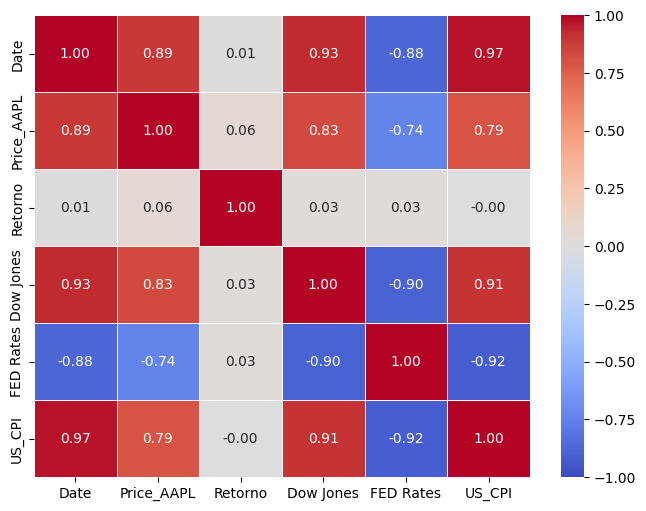

In [ ]:
# Heat map - correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

In [ ]:
data.columns

Index(['Date', 'Price_AAPL', 'Retorno', 'Dow Jones', 'FED Rates', 'US_CPI'], dtype='object')

In [ ]:
# OLS Model

In [ ]:

X = data[['Dow Jones', 'FED Rates', 'US_CPI']]

In [ ]:

X = sm.add_constant(X)


In [ ]:

y = data['Price_AAPL']

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

In [ ]:

model = sm.OLS(y_train, X_train).fit()

In [ ]:

y_pred = model.predict(X_test)


In [ ]:

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
# Print results
print("Resumen del modelo OLS:\n", model.summary())
print("\nMétricas de validación:")
print(f"Error Cuadrático Medio (MSE): {mse}")
print(f"R-cuadrado: {r2}")

Resumen del modelo OLS:
                             OLS Regression Results                            
Dep. Variable:             Price_AAPL   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     181.8
Date:                Sat, 05 Apr 2025   Prob (F-statistic):           3.43e-60
Time:                        17:57:53   Log-Likelihood:                -945.80
No. Observations:                 232   AIC:                             1900.
Df Residuals:                     228   BIC:                             1913.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1375.7273    32

In [ ]:
data.to_excel("data_market_risk.xlsx")

In [ ]:
# VIF Calculation and conclusions

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


X = data[['Dow Jones', 'FED Rates', 'US_CPI']].dropna()


X_const = add_constant(X)


vif_data = pd.DataFrame()
vif_data["Variable"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print(vif_data)

    Variable            VIF
0      const  110860.099639
1  Dow Jones       6.518354
2  FED Rates       7.579940
3     US_CPI       8.215476


**CONCLUSIONS:**


If we limit ourselves to looking at the results of the OLS regression and the correlation matrix, we find significant reasons to say that this model is very powerful, just to mention a couple of them, the OLS result shows a R-squared: 0.7 and also shows that p-values are less than 0.05, but at the same time, these results, the others shown in both the OLS summary and the correlation matrix are highly suspicious.

Let's start by analyzing the correlation matrix. We find the following correlations between the independent variables:

**Dow Jones - US_CPI:** 0.91 - High positive correlation.

**Dow Jones - Fed Rates:** -0.89 - High negative correlation.

**FED Rates - US_CPI:** -0.92 - High negative correlation.

The Dow Jones and US_CPI are already correlated with Fed Rates because when inflation (US_CPI) rises, the Fed usually raises rates. It is also well known that movements in the Dow Jones are also influenced by Fed decisions. Therefore, the model may be attributing to interest rates an effect that actually comes from the CPI or the Dow Jones, generating a "misleading" coefficient for Fed Rates.

These three variables are highly correlated with each other, which explains why the VIF for all of them is above 5. This indicates strong multicollinearity, that is, the variables are explaining each other rather than just Price_AAPL (Apple price). There is significant multicollinearity between the independent variables.

When two or more variables are highly correlated, the model cannot properly differentiate the individual effects of each. The estimated coefficients may have unexpected signs, may be unstable when new data are added, and may also have misleading p-values, which may appear significant but not actually be.

A possible solution would be to choose only one of the three variables, ideally the one most theoretically relevant to explaining the AAPL price for the purposes of our economic research.